# Loading images to a pandas dataframe tumor or not tumor

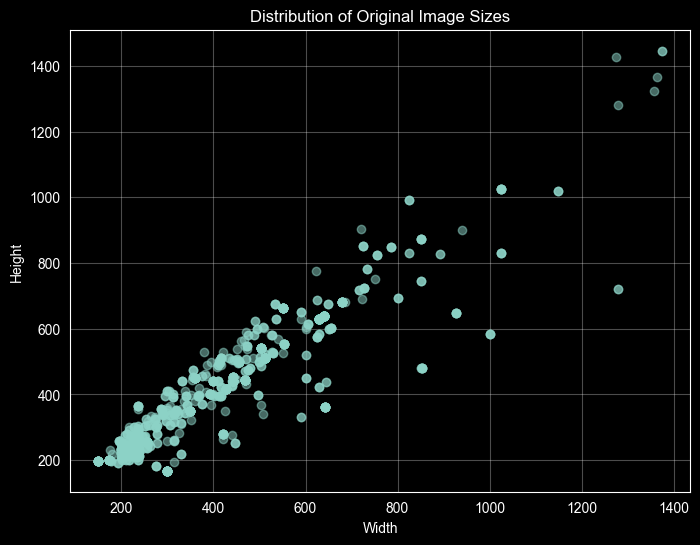

In [28]:
import os
import io
import numpy as np
import skimage as ski
import pandas as pd
import matplotlib.pyplot as plt
from skimage.feature import hog
import seaborn as sns

dataset_healthy = "./dataset/healthy"
dataset_tumor = "./dataset/tumor"
healthy_list = os.listdir(dataset_healthy)
tumor_list = os.listdir(dataset_tumor)

categories = [
    "healthy",
    "glioma",
    "meningioma",
    "pituitary",
    "tumor",
]

healthy_images = []
tumor_images = []

def categorize_img(name):
    for category in categories:
        if category in name:
            return category
    return "Unknown"


df = pd.DataFrame([], columns=["Img", "Tumor"])

# Collect original sizes
original_sizes = []

for img in healthy_list:
    read_img = ski.io.imread(dataset_healthy + "/" + img)
    original_sizes.append(read_img.shape[:2])  # height, width

for img in tumor_list:
    read_img = ski.io.imread(dataset_tumor + "/" + img)
    original_sizes.append(read_img.shape[:2])

heights = [s[0] for s in original_sizes]
widths = [s[1] for s in original_sizes]

plt.figure(figsize=(8,6))
plt.scatter(widths, heights, alpha=0.5)
plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Distribution of Original Image Sizes")
plt.grid(alpha=0.3)
plt.show()

# Normalize

Images can have different sizes or color space differences so we need to convert them to use the same color space and size, we will use size: 256x256 and Grayscale color space

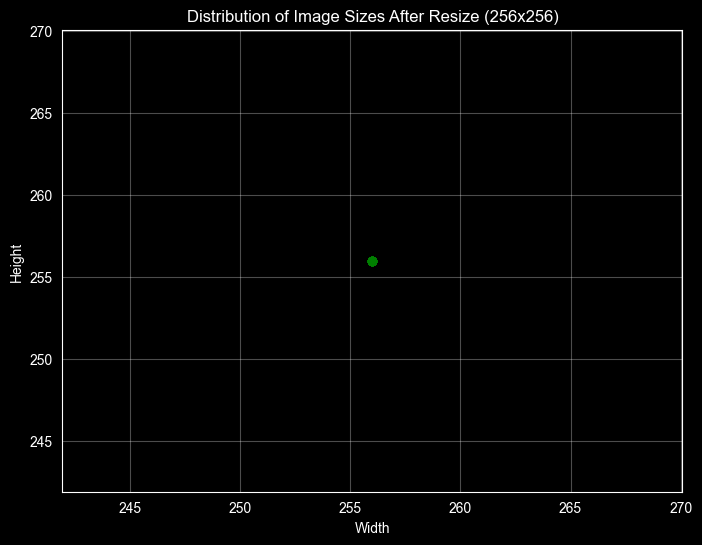

In [29]:
def normalize_color_space_img(img):
    if img.ndim == 2:
        return img
    elif img.ndim == 3:
        if img.shape[2] == 4:
            return ski.color.rgb2gray(ski.color.rgba2rgb(img))
        else:
            return ski.color.rgb2gray(img)
    else:
        print(f"Unexpected image shape: {img.shape}")
        return img

def normalize_size(img):
    return ski.transform.resize(img, (256, 256), anti_aliasing=True)

for img in healthy_list:
    read_img = ski.io.imread(dataset_healthy + "/" + img)
    df.loc[len(df)] = [normalize_size(normalize_color_space_img(read_img)), 0]

for img in tumor_list:
    read_img = ski.io.imread(dataset_tumor + "/" + img)
    df.loc[len(df)] = [normalize_size(normalize_color_space_img(read_img)), 1]

# Collect sizes after resizing
resized_sizes = []

for img_data in df["Img"]:
    resized_sizes.append(img_data.shape[:2])  # height, width

resized_heights = [s[0] for s in resized_sizes]
resized_widths = [s[1] for s in resized_sizes]

plt.figure(figsize=(8,6))
plt.scatter(resized_widths, resized_heights, alpha=0.5, color='green')
plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Distribution of Image Sizes After Resize (256x256)")
plt.grid(alpha=0.3)
plt.show()

# Dataframe stats

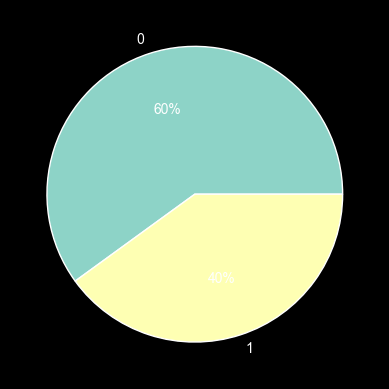

In [30]:
plt.pie(df["Tumor"].value_counts(), labels=["0", "1"], autopct='%.0f%%')
plt.show()

In [31]:
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn import svm

#X = df["Img"].apply(lambda x: x.flatten()).tolist()
X = df["Img"].apply(
    lambda img: hog(
        img,
        orientations=9,
        pixels_per_cell=(16,16),
        cells_per_block=(2,2),
        visualize=False
    )
).tolist()

Y = df["Tumor"].tolist()

X_train, X_test, Y_train, Y_test = train_test_split(X, Y,random_state=42,test_size=0.2)

clf = svm.SVC()
clf.fit(X_train, Y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [33]:
test_healthy = "./dataset/test_healthy"
test_tumor = "./dataset/test_tumor"
test_healthy_list = os.listdir(test_healthy)
test_tumor_list = os.listdir(test_tumor)

test = pd.DataFrame([], columns=["Img", "Tumor"])

for img in test_healthy_list:
    read_img = ski.io.imread(test_healthy + "/" + img)
    test.loc[len(test)] = [normalize_size(normalize_color_space_img(read_img)), 0]

for img in test_tumor_list:
    read_img = ski.io.imread(test_tumor + "/" + img)
    test.loc[len(test)] = [normalize_size(normalize_color_space_img(read_img)), 1]

Y_pred = clf.predict(X_test)
result = classification_report(Y_test, Y_pred)
print(result)

print("Test from other datasets:")

X_test = test["Img"].apply(
    lambda img: hog(
        img,
        orientations=9,
        pixels_per_cell=(16,16),
        cells_per_block=(2,2),
        visualize=False
    )
).tolist()
Y_test = test["Tumor"].tolist()
Y_pred = clf.predict(X_test)
result = classification_report(Y_test, Y_pred)
print(result)

              precision    recall  f1-score   support

           0       0.98      0.97      0.97       406
           1       0.98      0.98      0.98       594

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000

Test from other datasets:
              precision    recall  f1-score   support

           0       0.49      0.99      0.65       389
           1       0.86      0.04      0.08       426

    accuracy                           0.50       815
   macro avg       0.68      0.52      0.37       815
weighted avg       0.68      0.50      0.36       815

